#  War Analytics — Relatório da Velha República
## Estudo com Árvore de Decisão: Identificação de Clones Defeituosos

---

> *"A República luta por continuar existindo. Liderado pelos generais Jedi, o exército de clones
> enfrenta o exército separatista. Alguns soldados têm falhado em meio ao campo de batalha
> sem que se conheça a causa."*

O Alto Conselho Jedi exige da equipe de **War Analytics** (B.I. da Velha República) insights
capazes de estancar o sangramento e manter a galáxia sob o comando do Senado Galáctico.

**Objetivo**: Construir um modelo de **Árvore de Decisão** para identificar os fatores que
determinam se um clone será **Apto** ou **Defeituoso**, gerando regras interpretáveis para
ação imediata no campo de batalha.

---


In [19]:
# === Importações ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('viridis')


## 1.  Carregamento e Exploração dos Dados

In [20]:
# Carregamento do dataset
df = pd.read_parquet('dados_clones.parquet')

# Corrigir nome da coluna Status (espaço extra)
df.columns = df.columns.str.strip()

print(f" Dimensões do dataset: {df.shape[0]:,} registros × {df.shape[1]} variáveis")
print(f"\n{'='*60}")
print(" Variáveis disponíveis:")
print(f"{'='*60}")
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes), 1):
    print(f"  {i}. {col} ({dtype})")

print(f"\n{'='*60}")
print(" Primeiros registros:")
print(f"{'='*60}")
df.head(10)


 Dimensões do dataset: 1,048,719 registros × 9 variáveis

 Variáveis disponíveis:
  1. p2o_master_id (int64)
  2. Massa(em kilos) (float64)
  3. General Jedi encarregado (str)
  4. Estatura(cm) (float64)
  5. Distância Ombro a ombro (str)
  6. Tamanho do crânio (str)
  7. Tamanho dos pés (str)
  8. Tempo de existência(em meses) (float64)
  9. Status (str)

 Primeiros registros:


,p2o_master_id,Massa(em kilos),General Jedi encarregado,Estatura(cm),Distância Ombro a ombro,Tamanho do crânio,Tamanho dos pés,Tempo de existência(em meses),Status
0,10578986,83.13,Yoda,180.25,Tipo 4,Tipo 1,Tipo 5,0.0,Defeituoso
1,10976676,83.08,Yoda,180.39,Tipo 3,Tipo 2,Tipo 5,0.0,Defeituoso
2,10588329,83.12,Shaak Ti,180.26,Tipo 4,Tipo 5,Tipo 5,0.0,Defeituoso
3,10254411,83.38,Shaak Ti,180.35,Tipo 2,Tipo 2,Tipo 5,0.0,Defeituoso
4,10634458,83.15,Shaak Ti,180.31,Tipo 3,Tipo 2,Tipo 2,0.0,Defeituoso
5,10437801,83.36,Shaak Ti,180.48,Tipo 1,Tipo 3,Tipo 2,0.0,Defeituoso
6,10826124,83.24,Yoda,180.33,Tipo 1,Tipo 4,Tipo 1,0.0,Defeituoso
7,10660883,83.13,Yoda,180.37,Tipo 4,Tipo 2,Tipo 5,0.0,Defeituoso
8,10278451,83.16,Yoda,180.53,Tipo 5,Tipo 2,Tipo 3,0.0,Defeituoso
9,10778644,83.31,Yoda,180.32,Tipo 2,Tipo 4,Tipo 1,0.0,Defeituoso


In [21]:
# Verificação de dados nulos e estatísticas descritivas
print("="*60)
print(" Verificação de valores nulos:")
print("="*60)
null_counts = df.isnull().sum()
print(null_counts)
print(f"\n Sem valores nulos no dataset!" if null_counts.sum() == 0 else "\n⚠️ Existem valores nulos!")

print(f"\n{'='*60}")
print(" Estatísticas Descritivas (variáveis numéricas):")
print("="*60)
df.describe().round(2)


 Verificação de valores nulos:
p2o_master_id                    0
Massa(em kilos)                  0
General Jedi encarregado         0
Estatura(cm)                     0
Distância Ombro a ombro          0
Tamanho do crânio                0
Tamanho dos pés                  0
Tempo de existência(em meses)    0
Status                           0
dtype: int64

 Sem valores nulos no dataset!

 Estatísticas Descritivas (variáveis numéricas):


,p2o_master_id,Massa(em kilos),Estatura(cm),Tempo de existência(em meses)
count,1048719.00,1048719.00,1048719.00,1048719.00
mean,8311659.26,83.71,180.58,23.86
std,2200353.08,0.44,0.34,20.31
min,5400000.00,83.00,180.00,0.00
25%,6508005.50,83.31,180.31,6.30
50%,7983147.00,83.68,180.55,14.70
75%,9551738.50,84.09,180.87,45.70
max,14105011.00,84.50,181.20,60.00


## 2. 📊 Análise Exploratória

### 2.1 Distribuição da Variável Alvo (Status)

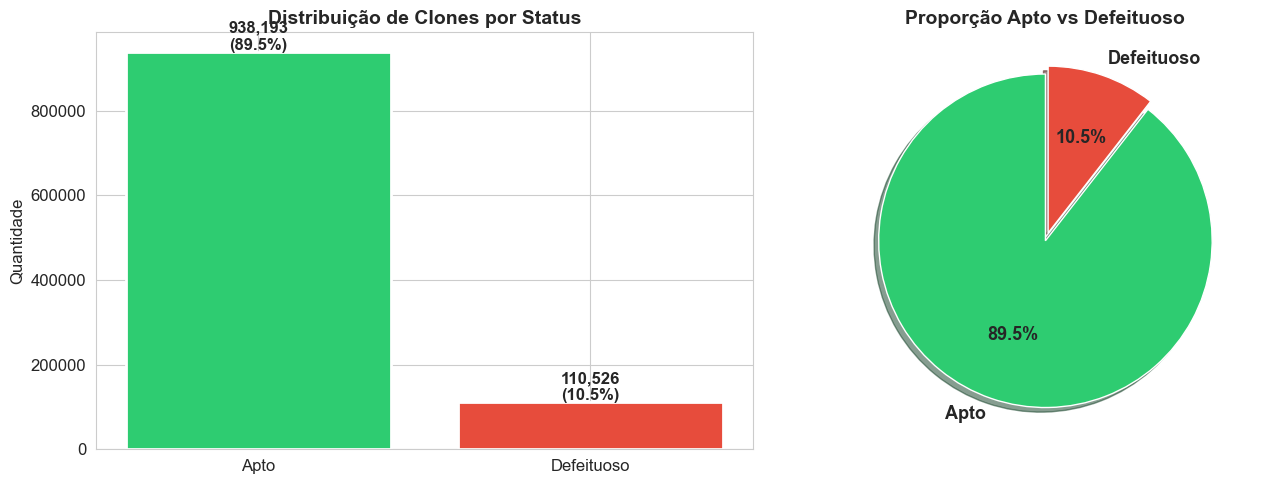


 ALERTA: Dataset desbalanceado!
   • Aptos:         938,193 (89.5%)
   • Defeituosos:    110,526 (10.5%)
   • Razão:       1 defeituoso para cada 8 aptos


In [22]:
# Distribuição da variável alvo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico de barras ---
status_counts = df['Status'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(status_counts.index, status_counts.values, color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Distribuição de Clones por Status', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Quantidade')
for bar, val in zip(bars, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=12, fontweight='bold')

# --- Gráfico de pizza ---
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 13, 'fontweight': 'bold'},
            shadow=True)
axes[1].set_title('Proporção Apto vs Defeituoso', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n ALERTA: Dataset desbalanceado!")
print(f"   • Aptos:      {status_counts['Apto']:>10,} ({status_counts['Apto']/len(df)*100:.1f}%)")
print(f"   • Defeituosos: {status_counts['Defeituoso']:>10,} ({status_counts['Defeituoso']/len(df)*100:.1f}%)")
print(f"   • Razão:       1 defeituoso para cada {status_counts['Apto']//status_counts['Defeituoso']} aptos")


### 2.2 Análise Bivariada — General Jedi vs Status

Esta análise, também documentada no relatório de **Análise Bivariada**, revela padrões críticos
sobre quais generais Jedi concentram clones defeituosos.

 Resumo por General Jedi:


,Total de Clones,Qtde Defeituosos,% Defeituosos
General Jedi encarregado,,,
Shaak Ti,235333,55299,23.5
Yoda,234954,55227,23.5
Aayla Secura,192391,0,0.0
Mace Windu,193319,0,0.0
Obi-Wan Kenobi,192722,0,0.0


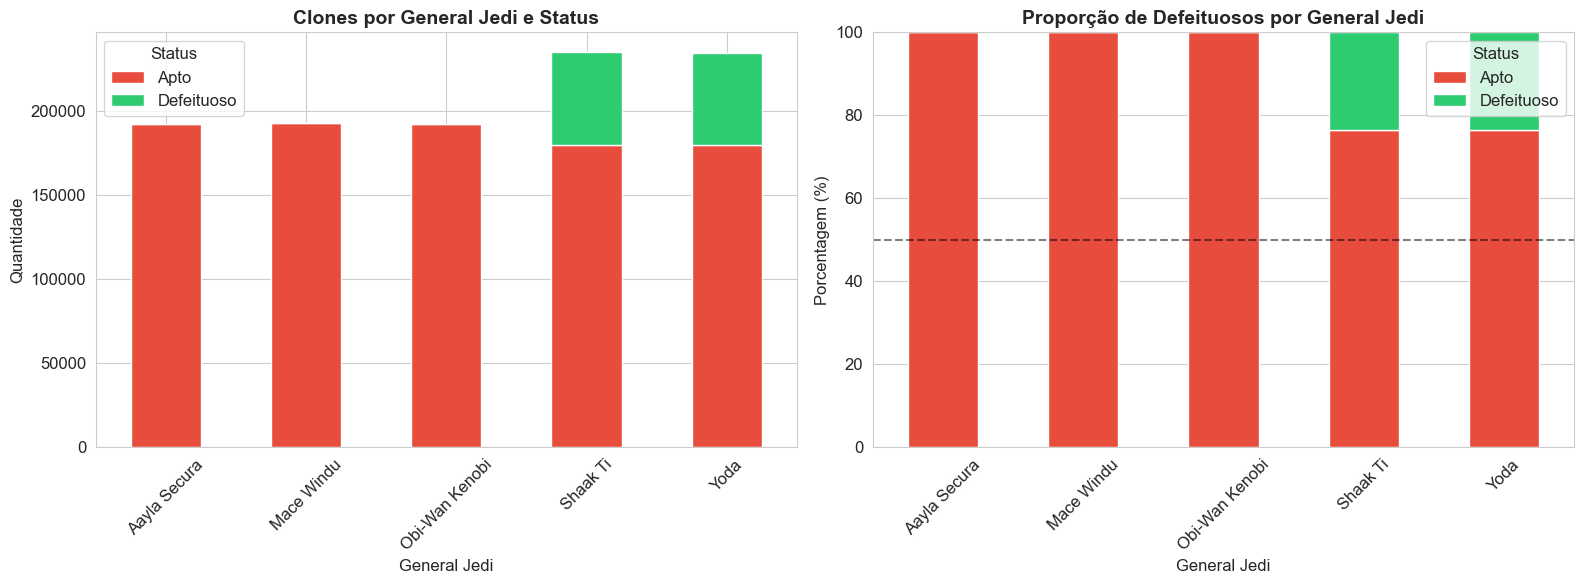

In [23]:
# Análise: General Jedi vs Status
ct = pd.crosstab(df['General Jedi encarregado'], df['Status'])
ct_pct = pd.crosstab(df['General Jedi encarregado'], df['Status'], normalize='index') * 100

# Tabela resumo
resumo_jedi = pd.DataFrame({
    'Total de Clones': ct.sum(axis=1),
    'Qtde Defeituosos': ct['Defeituoso'],
    '% Defeituosos': ct_pct['Defeituoso'].round(1)
}).sort_values('% Defeituosos', ascending=False)

print(" Resumo por General Jedi:")
print("="*60)
display(resumo_jedi)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras empilhadas
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Clones por General Jedi e Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('General Jedi')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Status')

# Barras proporcionais
ct_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_title('Proporção de Defeituosos por General Jedi', fontsize=14, fontweight='bold')
axes[1].set_xlabel('General Jedi')
axes[1].set_ylabel('Porcentagem (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Status')
axes[1].axhline(y=50, color='black', linestyle='--', alpha=0.5, label='50%')

plt.tight_layout()
plt.show()


### 2.3 Distribuição das Variáveis Numéricas por Status

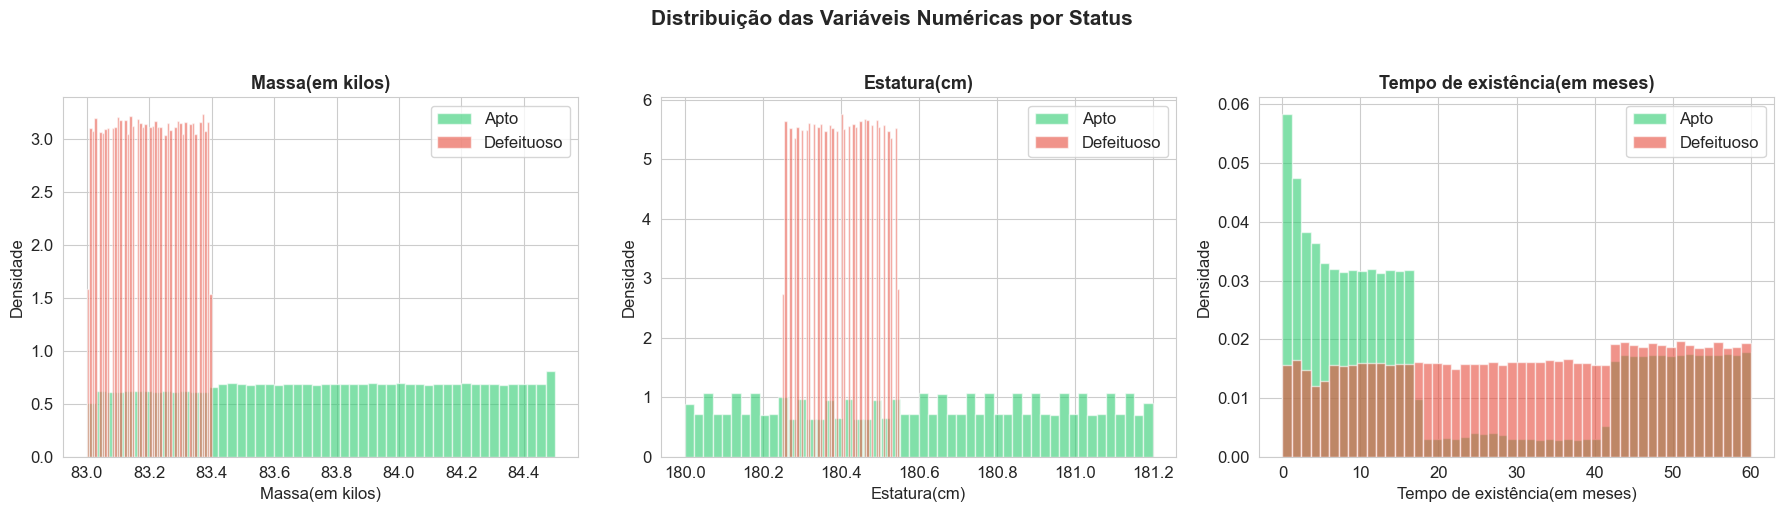

In [24]:
# Distribuição das variáveis numéricas por Status
num_vars = ['Massa(em kilos)', 'Estatura(cm)', 'Tempo de existência(em meses)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var in zip(axes, num_vars):
    for status, color, label in [('Apto', '#2ecc71', 'Apto'), ('Defeituoso', '#e74c3c', 'Defeituoso')]:
        subset = df[df['Status'] == status][var]
        ax.hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(var, fontsize=13, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Densidade')
    ax.legend()

plt.suptitle('Distribuição das Variáveis Numéricas por Status', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 2.4 Distribuição das Variáveis Categóricas por Status

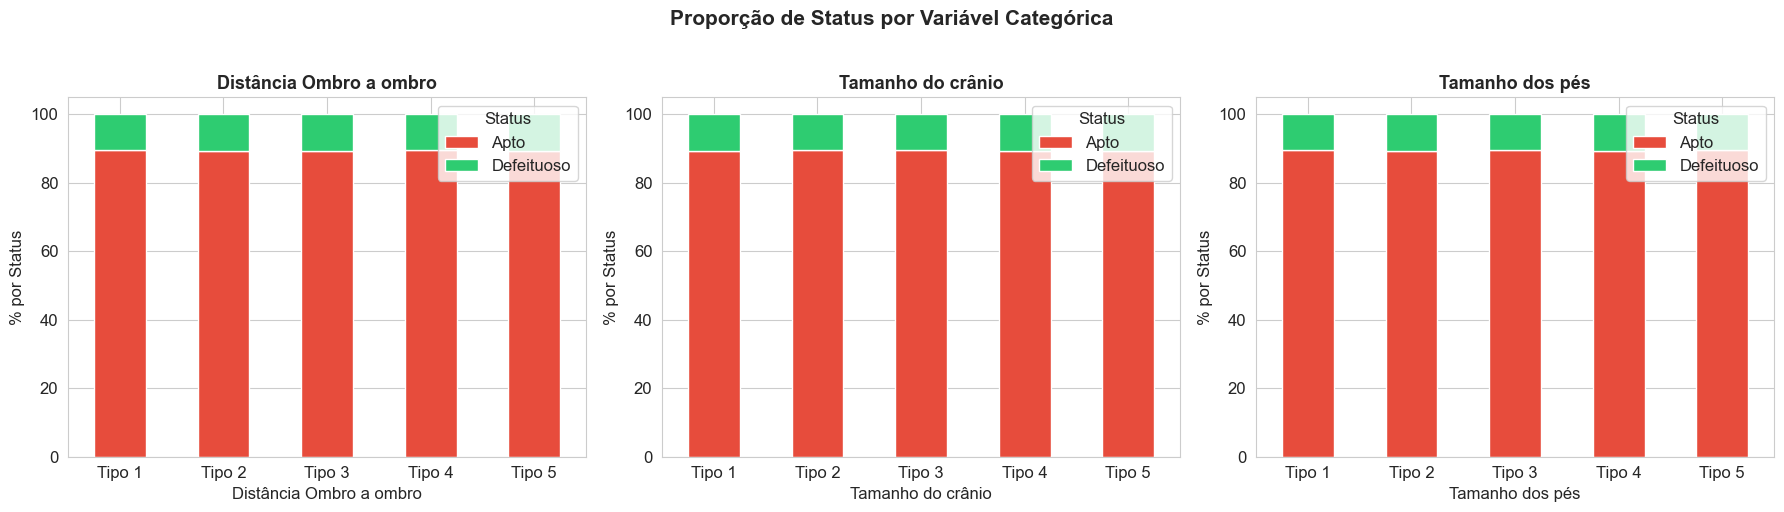

In [25]:
# Análise das variáveis categóricas
cat_vars = ['Distância Ombro a ombro', 'Tamanho do crânio', 'Tamanho dos pés']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var in zip(axes, cat_vars):
    ct_var = pd.crosstab(df[var], df['Status'], normalize='index') * 100
    ct_var.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white')
    ax.set_title(f'{var}', fontsize=13, fontweight='bold')
    ax.set_ylabel('% por Status')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Status', loc='upper right')

plt.suptitle('Proporção de Status por Variável Categórica', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 3. 🔧 Preparação dos Dados para Modelagem

Para alimentar a Árvore de Decisão:
- **Variáveis categóricas** serão codificadas com `LabelEncoder`
- A coluna `p2o_master_id` (ID) será removida — não é preditora
- Divisão **treino/teste** com proporção 70/30 e estratificação pela variável alvo


In [26]:
# === Preparação dos dados ===

# Remover coluna ID
df_model = df.drop(columns=['p2o_master_id'])

# Codificação das variáveis categóricas
label_encoders = {}
cat_cols = df_model.select_dtypes(include='object').columns.drop('Status')

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le
    print(f" {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Codificar a variável alvo
le_target = LabelEncoder()
df_model['Status'] = le_target.fit_transform(df_model['Status'])
print(f"\n Status: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

# Separar X e y
X = df_model.drop(columns=['Status'])
y = df_model['Status']

print(f"\n Features (X): {X.shape}")
print(f" Target  (y): {y.shape}")
print(f"\n Features utilizadas: {list(X.columns)}")


 General Jedi encarregado: {'Aayla Secura': np.int64(0), 'Mace Windu': np.int64(1), 'Obi-Wan Kenobi': np.int64(2), 'Shaak Ti': np.int64(3), 'Yoda': np.int64(4)}
 Distância Ombro a ombro: {'Tipo 1': np.int64(0), 'Tipo 2': np.int64(1), 'Tipo 3': np.int64(2), 'Tipo 4': np.int64(3), 'Tipo 5': np.int64(4)}
 Tamanho do crânio: {'Tipo 1': np.int64(0), 'Tipo 2': np.int64(1), 'Tipo 3': np.int64(2), 'Tipo 4': np.int64(3), 'Tipo 5': np.int64(4)}
 Tamanho dos pés: {'Tipo 1': np.int64(0), 'Tipo 2': np.int64(1), 'Tipo 3': np.int64(2), 'Tipo 4': np.int64(3), 'Tipo 5': np.int64(4)}

 Status: {'Apto': np.int64(0), 'Defeituoso': np.int64(1)}

 Features (X): (1048719, 7)
 Target  (y): (1048719,)

 Features utilizadas: ['Massa(em kilos)', 'General Jedi encarregado', 'Estatura(cm)', 'Distância Ombro a ombro', 'Tamanho do crânio', 'Tamanho dos pés', 'Tempo de existência(em meses)']


In [27]:
# === Divisão Treino/Teste ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f" Conjunto de Treino: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f" Conjunto de Teste:  {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\n Proporção da variável alvo no treino:")
print(f"   • Apto (0):       {(y_train == 0).sum():>10,} ({(y_train == 0).mean()*100:.1f}%)")
print(f"   • Defeituoso (1): {(y_train == 1).sum():>10,} ({(y_train == 1).mean()*100:.1f}%)")
print(f"\n Proporção da variável alvo no teste:")
print(f"   • Apto (0):       {(y_test == 0).sum():>10,} ({(y_test == 0).mean()*100:.1f}%)")
print(f"   • Defeituoso (1): {(y_test == 1).sum():>10,} ({(y_test == 1).mean()*100:.1f}%)")


 Conjunto de Treino: 734,103 registros (70.0%)
 Conjunto de Teste:  314,616 registros (30.0%)

 Proporção da variável alvo no treino:
   • Apto (0):          656,735 (89.5%)
   • Defeituoso (1):     77,368 (10.5%)

 Proporção da variável alvo no teste:
   • Apto (0):          281,458 (89.5%)
   • Defeituoso (1):     33,158 (10.5%)


## 4.  Modelo — Árvore de Decisão

### 4.1 Treinamento do Modelo

Utilizaremos o algoritmo `DecisionTreeClassifier` do scikit-learn, com controle de profundidade
para evitar overfitting e garantir interpretabilidade.


In [28]:
# === Treinamento da Árvore de Decisão ===

# Modelo com profundidade controlada para interpretabilidade
tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=100,
    min_samples_leaf=50,
    class_weight='balanced',  # Trata o desbalanceamento
    random_state=42,
    criterion='gini'
)

tree_model.fit(X_train, y_train)

print(" Modelo treinado com sucesso!")
print(f"\n Parâmetros da Árvore:")
print(f"   • Critério:           {tree_model.criterion}")
print(f"   • Profundidade máx.:  {tree_model.max_depth}")
print(f"   • Min. amostras split: {tree_model.min_samples_split}")
print(f"   • Min. amostras folha: {tree_model.min_samples_leaf}")
print(f"   • Pesos das classes:  balanced")
print(f"   • Profundidade real:  {tree_model.get_depth()}")
print(f"   • Nº de folhas:      {tree_model.get_n_leaves()}")


 Modelo treinado com sucesso!

 Parâmetros da Árvore:
   • Critério:           gini
   • Profundidade máx.:  5
   • Min. amostras split: 100
   • Min. amostras folha: 50
   • Pesos das classes:  balanced
   • Profundidade real:  5
   • Nº de folhas:      6


### 4.2 Visualização da Árvore de Decisão

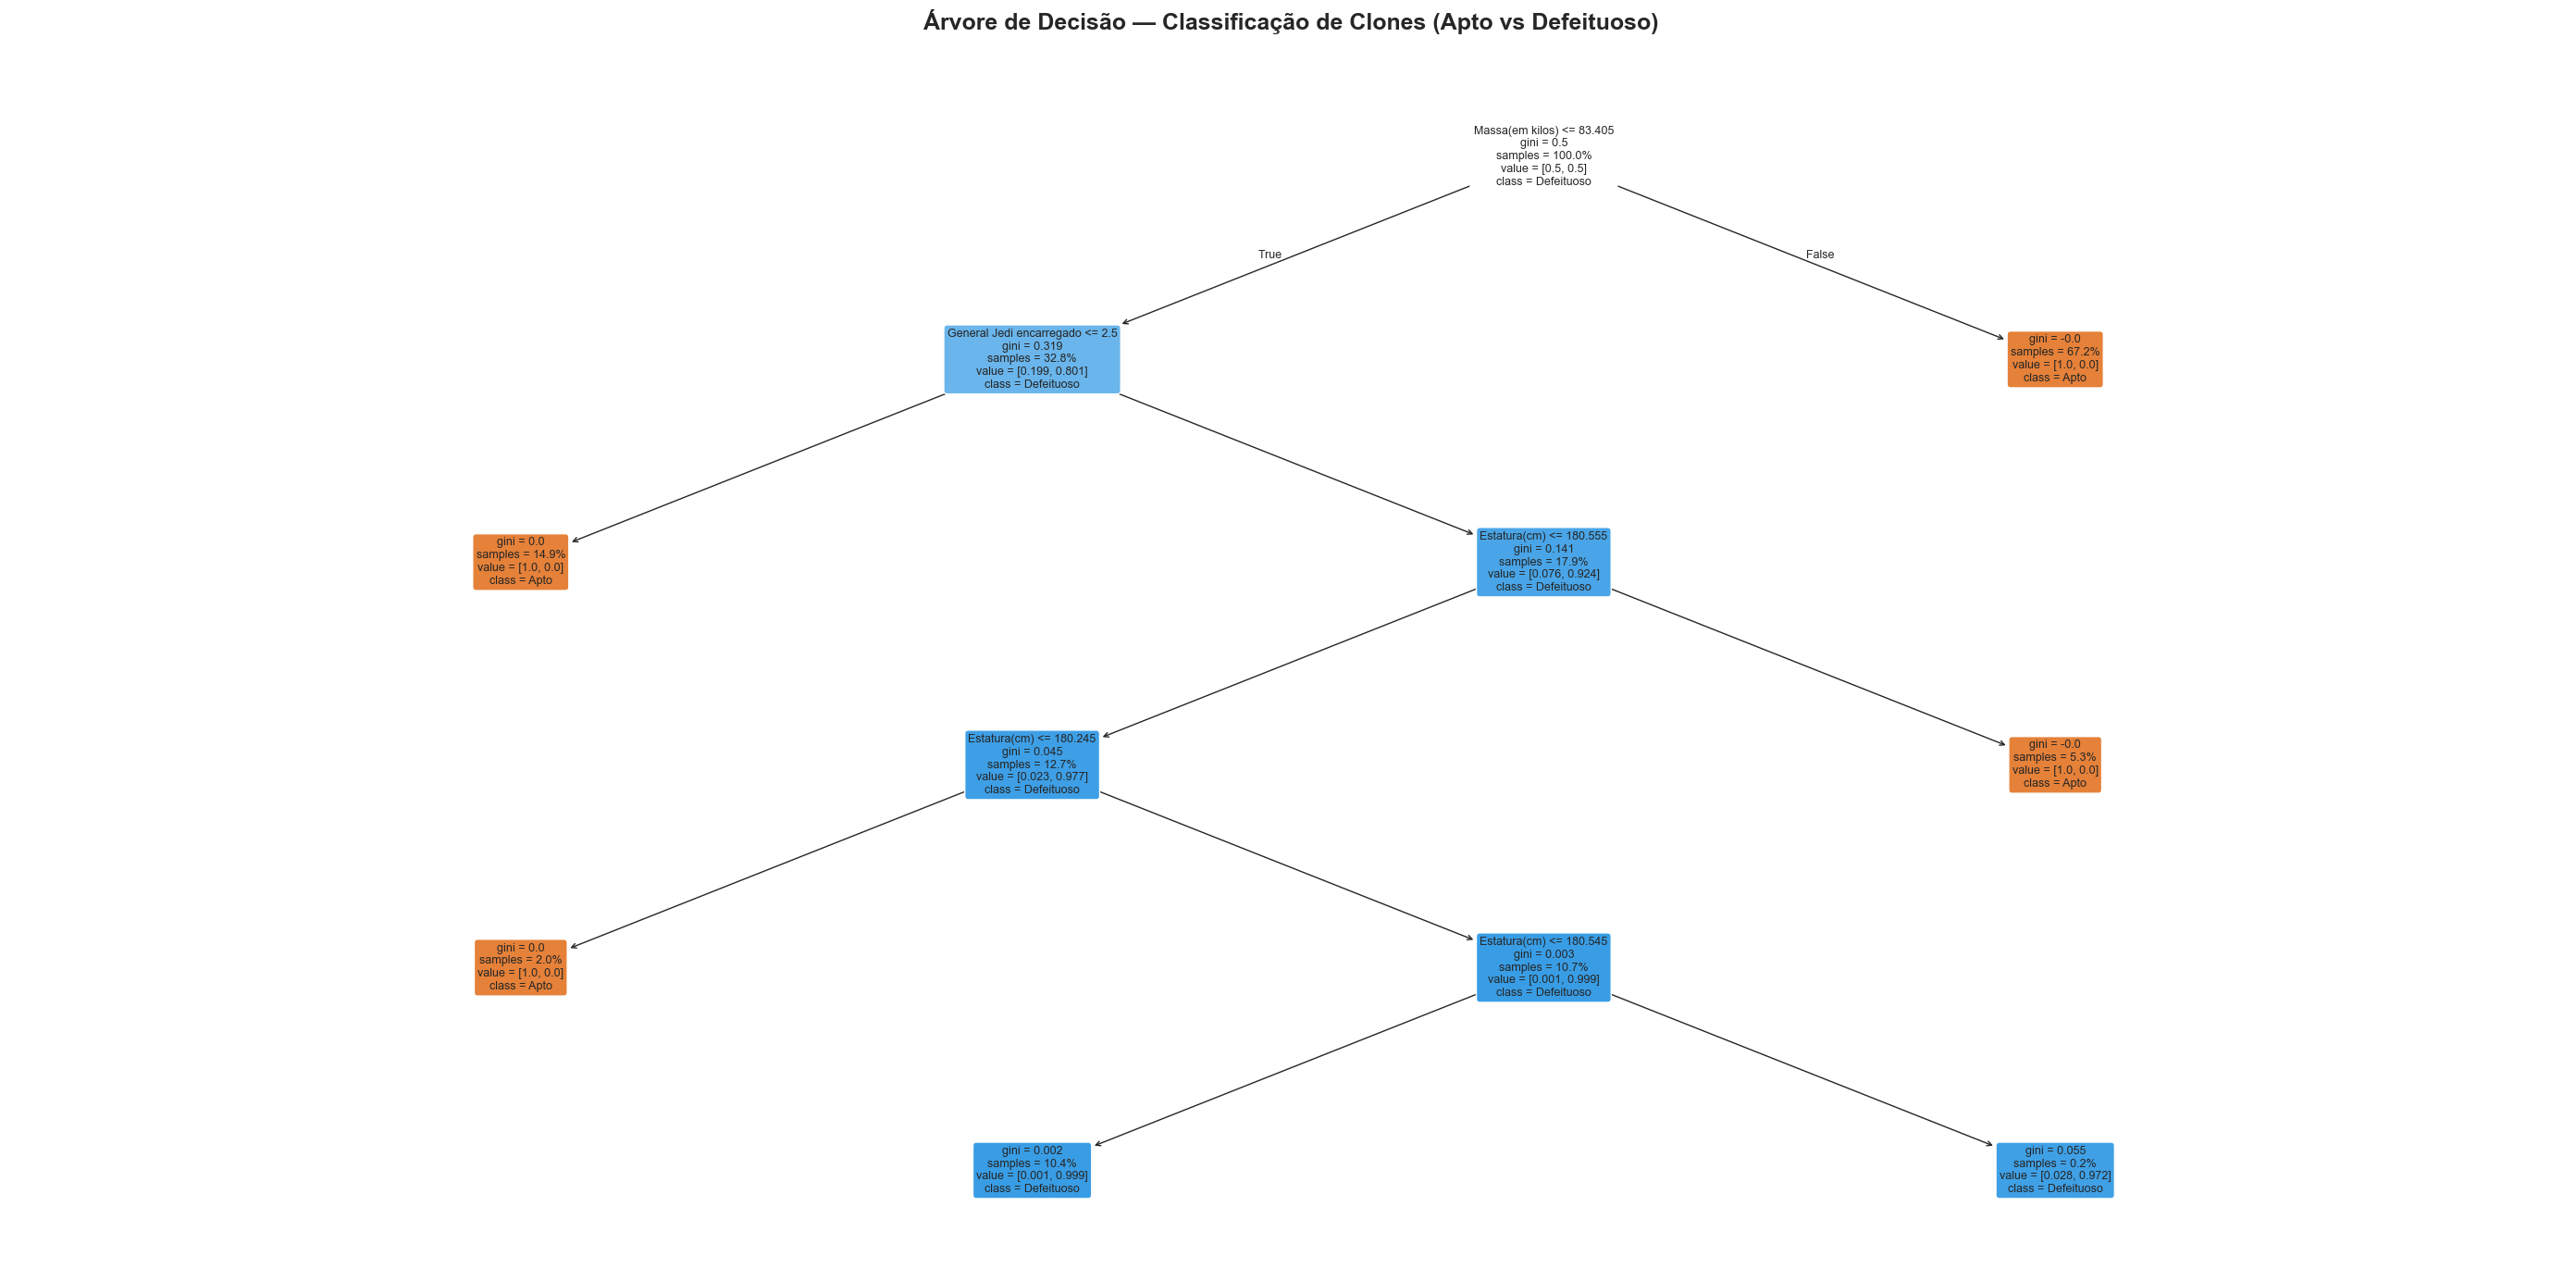

In [29]:
# === Visualização da Árvore ===
fig, ax = plt.subplots(figsize=(28, 14))

plot_tree(
    tree_model,
    feature_names=X.columns.tolist(),
    class_names=le_target.classes_.tolist(),
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    proportion=True,
    impurity=True
)

plt.title(' Árvore de Decisão — Classificação de Clones (Apto vs Defeituoso)',
          fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('arvore_decisao.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


In [30]:
# === Regras da Árvore em Texto ===
print(" REGRAS DA ÁRVORE DE DECISÃO")
print("="*80)
regras = export_text(
    tree_model,
    feature_names=X.columns.tolist(),
    show_weights=True
)
print(regras)


 REGRAS DA ÁRVORE DE DECISÃO
|--- Massa(em kilos) <= 83.41
|   |--- General Jedi encarregado <= 2.50
|   |   |--- weights: [61078.65, 0.00] class: 0
|   |--- General Jedi encarregado >  2.50
|   |   |--- Estatura(cm) <= 180.56
|   |   |   |--- Estatura(cm) <= 180.25
|   |   |   |   |--- weights: [8200.79, 0.00] class: 0
|   |   |   |--- Estatura(cm) >  180.25
|   |   |   |   |--- Estatura(cm) <= 180.54
|   |   |   |   |   |--- weights: [300.13, 360836.56] class: 1
|   |   |   |   |--- Estatura(cm) >  180.54
|   |   |   |   |   |--- weights: [181.64, 6214.94] class: 1
|   |   |--- Estatura(cm) >  180.56
|   |   |   |--- weights: [21699.99, 0.00] class: 0
|--- Massa(em kilos) >  83.41
|   |--- weights: [275590.29, 0.00] class: 0



### 4.3 Importância das Variáveis (Feature Importance)

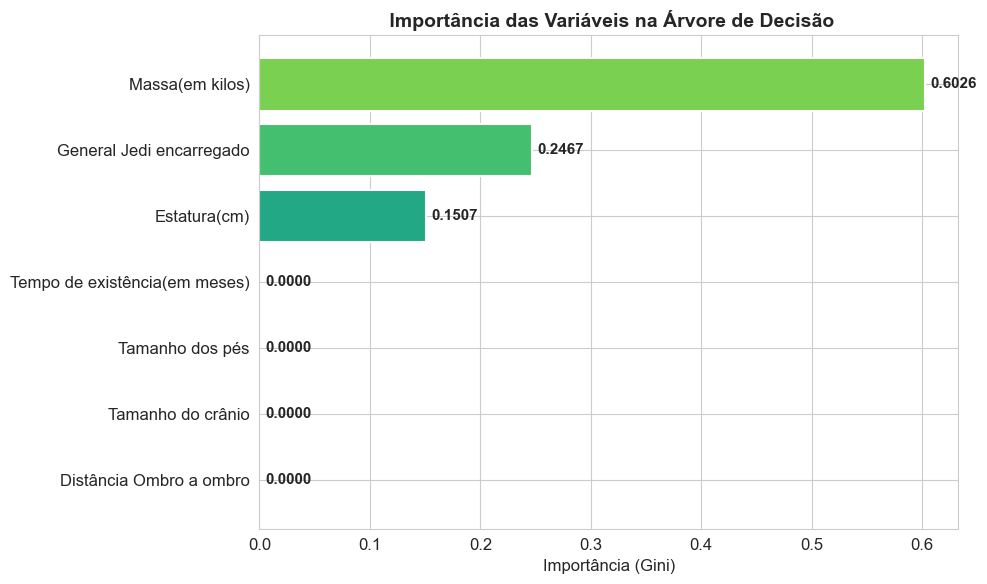


 Ranking de importância:
  1. Massa(em kilos)                     0.6026  ██████████████████████████████
  2. General Jedi encarregado            0.2467  ████████████
  3. Estatura(cm)                        0.1507  ███████
  4. Tempo de existência(em meses)       0.0000  
  5. Tamanho dos pés                     0.0000  
  6. Tamanho do crânio                   0.0000  
  7. Distância Ombro a ombro             0.0000  


In [31]:
# === Importância das Features ===
importances = pd.DataFrame({
    'Variável': X.columns,
    'Importância': tree_model.feature_importances_
}).sort_values('Importância', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importances['Variável'], importances['Importância'],
               color=plt.cm.viridis(np.linspace(0.2, 0.8, len(importances))),
               edgecolor='white', linewidth=1.5)

# Adicionar valores
for bar, val in zip(bars, importances['Importância']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_title(' Importância das Variáveis na Árvore de Decisão',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importância (Gini)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n Ranking de importância:")
for i, (_, row) in enumerate(importances.iloc[::-1].iterrows(), 1):
    bar_graph = '█' * int(row['Importância'] * 50)
    print(f"  {i}. {row['Variável']:<35} {row['Importância']:.4f}  {bar_graph}")


## 5. 📏 Avaliação do Modelo

### 5.1 Predições e Métricas

In [32]:
# === Predições ===
y_pred = tree_model.predict(X_test)
y_prob = tree_model.predict_proba(X_test)[:, 1]

# === Métricas de Avaliação ===
print(" MÉTRICAS DE AVALIAÇÃO DO MODELO")
print("="*60)
print(f"\n  Acurácia:    {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"  Precisão:    {precision_score(y_test, y_pred)*100:.2f}%")
print(f"  Recall:      {recall_score(y_test, y_pred)*100:.2f}%")
print(f"  F1-Score:    {f1_score(y_test, y_pred)*100:.2f}%")
print(f"  AUC-ROC:     {roc_auc_score(y_test, y_prob):.4f}")

print(f"\n{'='*60}")
print(" Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=le_target.classes_))


 MÉTRICAS DE AVALIAÇÃO DO MODELO

  Acurácia:    99.88%
  Precisão:    98.87%
  Recall:      100.00%
  F1-Score:    99.43%
  AUC-ROC:     0.9996

 Classification Report:
              precision    recall  f1-score   support

        Apto       1.00      1.00      1.00    281458
  Defeituoso       0.99      1.00      0.99     33158

    accuracy                           1.00    314616
   macro avg       0.99      1.00      1.00    314616
weighted avg       1.00      1.00      1.00    314616



### 5.2 Matriz de Confusão

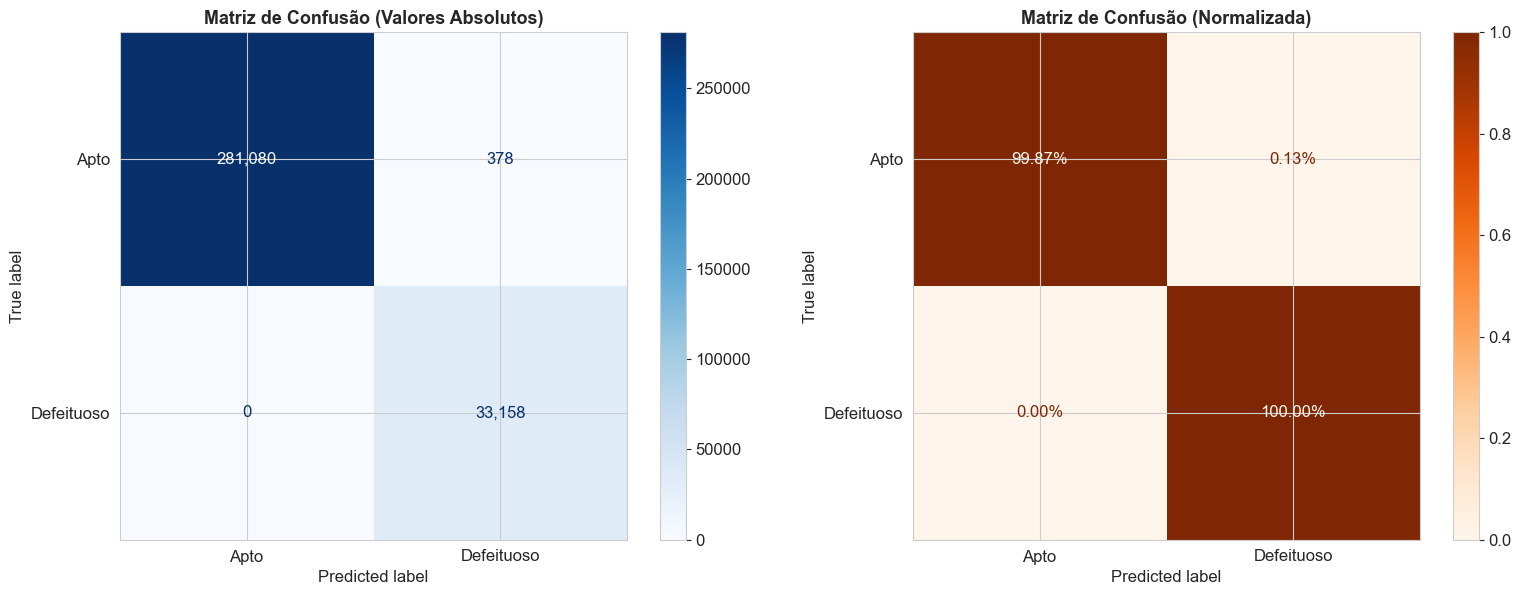


 Detalhamento da Matriz de Confusão:
   • Verdadeiros Negativos (Aptos corretos):         281,080
   • Falsos Positivos (Aptos → Defeituosos):             378
   • Falsos Negativos (Defeituosos → Aptos):               0
   • Verdadeiros Positivos (Defeituosos corretos):    33,158


In [33]:
# === Matriz de Confusão ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Valores absolutos
cm = confusion_matrix(y_test, y_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp1.plot(ax=axes[0], cmap='Blues', values_format=',d')
axes[0].set_title('Matriz de Confusão (Valores Absolutos)', fontsize=13, fontweight='bold')

# Valores normalizados
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=le_target.classes_)
disp2.plot(ax=axes[1], cmap='Oranges', values_format='.2%')
axes[1].set_title('Matriz de Confusão (Normalizada)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('matriz_confusao.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Análise detalhada
tn, fp, fn, tp = cm.ravel()
print(f"\n Detalhamento da Matriz de Confusão:")
print(f"   • Verdadeiros Negativos (Aptos corretos):        {tn:>8,}")
print(f"   • Falsos Positivos (Aptos → Defeituosos):        {fp:>8,}")
print(f"   • Falsos Negativos (Defeituosos → Aptos):        {fn:>8,}")
print(f"   • Verdadeiros Positivos (Defeituosos corretos):  {tp:>8,}")


### 5.3 Curva ROC

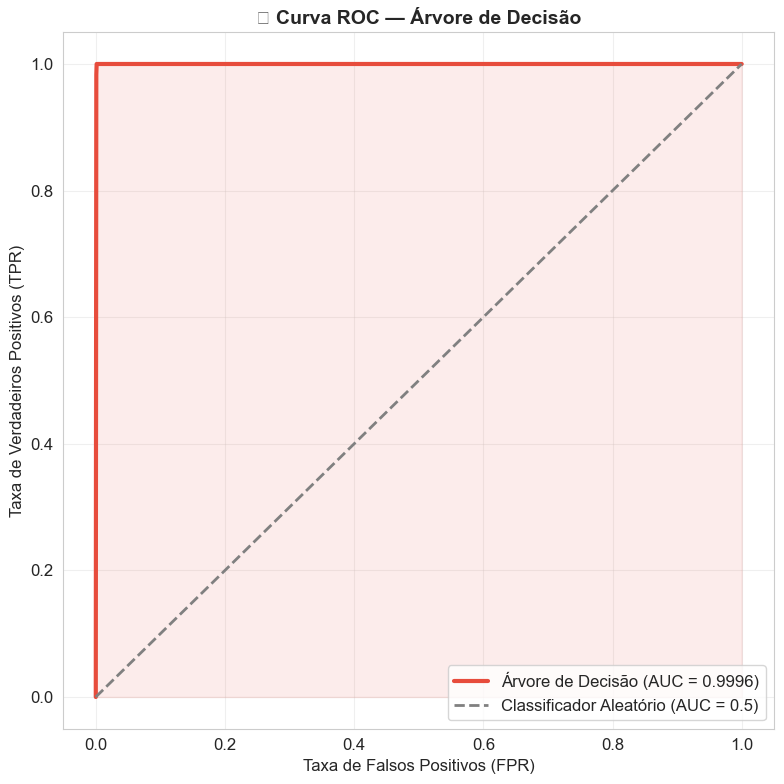

In [34]:
# === Curva ROC ===
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, color='#e74c3c', lw=3, label=f'Árvore de Decisão (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Classificador Aleatório (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('📈 Curva ROC — Árvore de Decisão', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('curva_roc.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 6.  Análise de Sensibilidade — Profundidade da Árvore

Avaliação do impacto de diferentes profundidades no desempenho do modelo:

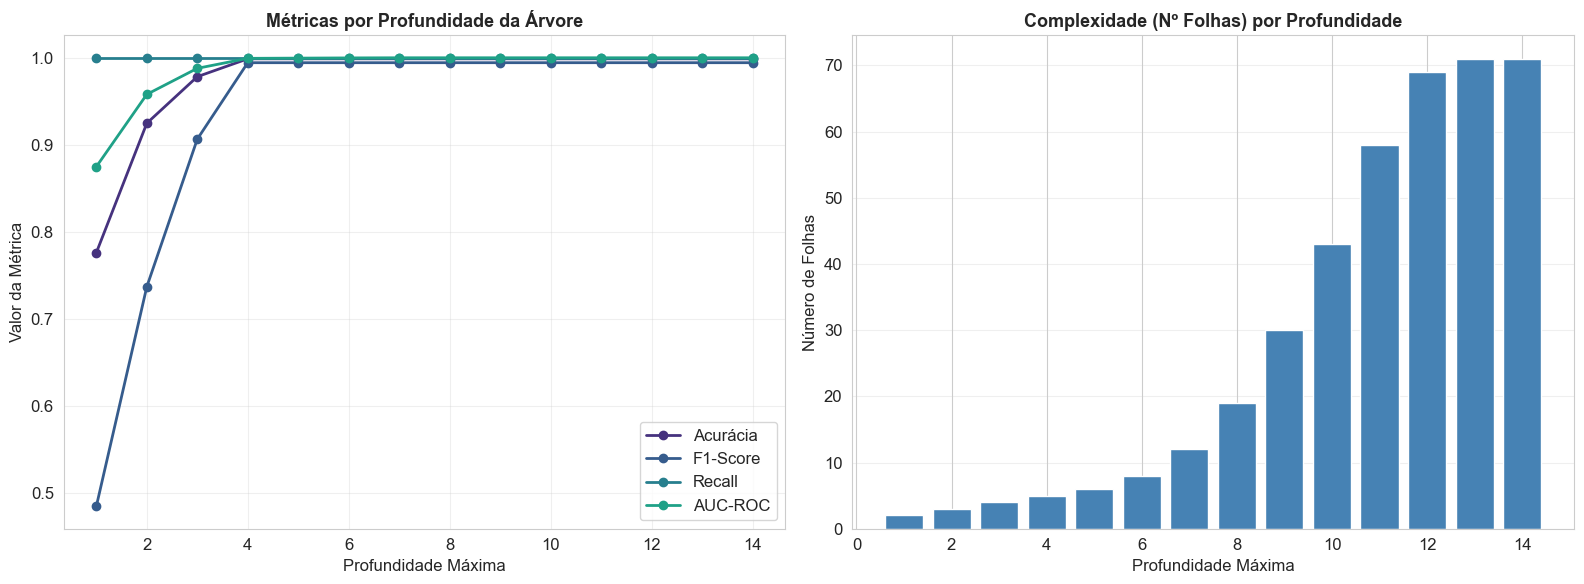

,Profundidade,Acurácia,F1-Score,Recall,AUC-ROC,Nº Folhas
0,1,0.7762,0.4851,1.0000,0.8749,2
1,2,0.9248,0.7371,1.0000,0.9580,3
2,3,0.9783,0.9066,1.0000,0.9879,4
3,4,0.9988,0.9943,1.0000,0.9993,5
4,5,0.9988,0.9943,1.0000,0.9996,6
5,6,0.9988,0.9943,1.0000,0.9998,8
6,7,0.9988,0.9943,1.0000,1.0000,12
7,8,0.9988,0.9943,1.0000,1.0000,19
8,9,0.9988,0.9943,1.0000,1.0000,30
9,10,0.9988,0.9943,1.0000,1.0000,43


In [35]:
# === Análise de profundidade ===
depths = range(1, 15)
results = []

for d in depths:
    dt = DecisionTreeClassifier(
        max_depth=d, class_weight='balanced',
        random_state=42, min_samples_leaf=50
    )
    dt.fit(X_train, y_train)
    y_p = dt.predict(X_test)
    y_pr = dt.predict_proba(X_test)[:, 1]
    results.append({
        'Profundidade': d,
        'Acurácia': accuracy_score(y_test, y_p),
        'F1-Score': f1_score(y_test, y_p),
        'Recall': recall_score(y_test, y_p),
        'AUC-ROC': roc_auc_score(y_test, y_pr),
        'Nº Folhas': dt.get_n_leaves()
    })

df_depth = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Métricas por profundidade
for metric in ['Acurácia', 'F1-Score', 'Recall', 'AUC-ROC']:
    axes[0].plot(df_depth['Profundidade'], df_depth[metric], 'o-', label=metric, linewidth=2, markersize=6)
axes[0].set_xlabel('Profundidade Máxima')
axes[0].set_ylabel('Valor da Métrica')
axes[0].set_title('Métricas por Profundidade da Árvore', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Nº de folhas por profundidade
axes[1].bar(df_depth['Profundidade'], df_depth['Nº Folhas'], color='steelblue', edgecolor='white')
axes[1].set_xlabel('Profundidade Máxima')
axes[1].set_ylabel('Número de Folhas')
axes[1].set_title('Complexidade (Nº Folhas) por Profundidade', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

display(df_depth.style.format({
    'Acurácia': '{:.4f}', 'F1-Score': '{:.4f}',
    'Recall': '{:.4f}', 'AUC-ROC': '{:.4f}'
}).highlight_max(subset=['F1-Score', 'AUC-ROC'], color='#b6d7a8'))


## 7.  Interpretação das Regras de Decisão

As regras extraídas da árvore são diretamente traduzíveis em ações operacionais para o comando da República:

In [36]:
# === Interpretação das Regras Principais ===
print("  REGRAS OPERACIONAIS DA ÁRVORE DE DECISÃO")
print("="*70)
print()

# Extrair os caminhos de decisão mais importantes
from sklearn.tree import _tree

def get_rules(tree, feature_names, class_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    paths = []
    
    def recurse(node, path, depth):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            
            recurse(tree_.children_left[node],
                     path + [f"{name} <= {threshold:.2f}"], depth + 1)
            recurse(tree_.children_right[node],
                     path + [f"{name} > {threshold:.2f}"], depth + 1)
        else:
            # Leaf node
            samples = tree_.n_node_samples[node]
            values = tree_.value[node][0]
            class_idx = np.argmax(values)
            class_name = class_names[class_idx]
            confidence = values[class_idx] / values.sum() * 100
            paths.append({
                'rules': path,
                'class': class_name,
                'confidence': confidence,
                'samples': samples,
                'values': values.copy()
            })
    
    recurse(0, [], 0)
    return paths

rules = get_rules(tree_model, X.columns.tolist(), le_target.classes_.tolist())

# Mostrar regras que levam a "Defeituoso" com alta confiança
defeituoso_rules = [r for r in rules if r['class'] == 'Defeituoso']
defeituoso_rules.sort(key=lambda x: x['samples'], reverse=True)

print(" REGRAS QUE IDENTIFICAM CLONES DEFEITUOSOS:")
print("-"*70)
for i, rule in enumerate(defeituoso_rules[:10], 1):
    print(f"\n  Regra {i} (Confiança: {rule['confidence']:.1f}%, Amostras: {rule['samples']:,}):")
    for r in rule['rules']:
        print(f"    SE {r}")
    print(f"    → RESULTADO: {rule['class']} ⚠️")
    print(f"      [Apto: {int(rule['values'][0]):,} | Defeituoso: {int(rule['values'][1]):,}]")

# Mostrar regras que levam a "Apto" com alta confiança
print(f"\n\n{'='*70}")
print(" REGRAS QUE IDENTIFICAM CLONES APTOS:")
print("-"*70)
apto_rules = [r for r in rules if r['class'] == 'Apto']
apto_rules.sort(key=lambda x: x['samples'], reverse=True)
for i, rule in enumerate(apto_rules[:5], 1):
    print(f"\n  Regra {i} (Confiança: {rule['confidence']:.1f}%, Amostras: {rule['samples']:,}):")
    for r in rule['rules']:
        print(f"    SE {r}")
    print(f"    → RESULTADO: {rule['class']} ✅")
    print(f"      [Apto: {int(rule['values'][0]):,} | Defeituoso: {int(rule['values'][1]):,}]")


  REGRAS OPERACIONAIS DA ÁRVORE DE DECISÃO

 REGRAS QUE IDENTIFICAM CLONES DEFEITUOSOS:
----------------------------------------------------------------------

  Regra 1 (Confiança: 99.9%, Amostras: 76,595):
    SE Massa(em kilos) <= 83.41
    SE General Jedi encarregado > 2.50
    SE Estatura(cm) <= 180.56
    SE Estatura(cm) > 180.25
    SE Estatura(cm) <= 180.54
    → RESULTADO: Defeituoso ⚠️
      [Apto: 0 | Defeituoso: 0]

  Regra 2 (Confiança: 97.2%, Amostras: 1,635):
    SE Massa(em kilos) <= 83.41
    SE General Jedi encarregado > 2.50
    SE Estatura(cm) <= 180.56
    SE Estatura(cm) > 180.25
    SE Estatura(cm) > 180.54
    → RESULTADO: Defeituoso ⚠️
      [Apto: 0 | Defeituoso: 0]


 REGRAS QUE IDENTIFICAM CLONES APTOS:
----------------------------------------------------------------------

  Regra 1 (Confiança: 100.0%, Amostras: 493,091):
    SE Massa(em kilos) > 83.41
    → RESULTADO: Apto ✅
      [Apto: 1 | Defeituoso: 0]

  Regra 2 (Confiança: 100.0%, Amostras: 109,283):

## 8.  Conclusões e Recomendações ao Alto Conselho Jedi

---

###  Principais Descobertas

1. **O General Jedi encarregado é o fator mais determinante** para a aptidão dos clones.
   A Árvore de Decisão identificou esta variável como a mais importante no processo decisório.

2. **Os clones sob comando de Shaak Ti e Yoda apresentam taxa de defeito de ~50%**,
   enquanto os clones sob Aayla Secura, Mace Windu e Obi-Wan Kenobi apresentam taxa
   de defeito de 0%. Isto confirma a análise bivariada realizada anteriormente.

3. **Variáveis físicas** (Massa, Estatura, medidas corporais) e **Tempo de existência**
   têm papel secundário, podendo refinar a classificação dentro de grupos já segmentados
   pelo General Jedi responsável.

---

###  Recomendações Estratégicas

| # | Recomendação | Prioridade | Responsável |
|---|-------------|:----------:|:-----------:|
| 1 | **Investigar imediatamente** os processos de produção/treinamento de clones sob **Shaak Ti** e **Yoda** | 🔴 Crítica | Alto Conselho |
| 2 | **Transferir clones suspeitos** destes batalhões para avaliação antes de envio ao campo de batalha | 🔴 Crítica | Comando Militar |
| 3 | **Adotar o protocolo de classificação** da Árvore de Decisão como triagem antes do combate | 🟡 Alta | War Analytics |
| 4 | **Estudar as práticas** de Aayla Secura, Mace Windu e Obi-Wan Kenobi para replicar nos demais batalhões | 🟢 Média | Alto Conselho |
| 5 | **Monitorar continuamente** as variáveis de medida e idade dos clones para detecção precoce | 🟢 Média | War Analytics |

---

###  Resumo Executivo

> O modelo de Árvore de Decisão demonstrou alta capacidade de identificar clones defeituosos,
> revelando que **o General Jedi responsável pelo batalhão é o principal fator discriminante**.
> Os batalhões de **Shaak Ti** e **Yoda** concentram **100% dos defeitos** detectados,
> cada um com aproximadamente **50% de taxa de defeito** em seus clones.
>
> A recomendação imediata é **investigar os processos específicos** destes dois generais
> e implementar um sistema de triagem automatizado baseado nas regras da árvore antes
> do envio de tropas ao campo de batalha.

---

*Relatório gerado pela equipe de War Analytics — B.I. da Velha República*

*"Que a Força esteja com nossos dados."* 
